In [1]:
from backend.utils.gmsh_function import *
from backend.src.radiation_algorithm.radiation_algorithm import *
from backend.utils.file_path import *
from backend.rwg.rwg6 import plot_surface_current_distribution

from backend.efield.efield1 import *
from backend.efield.efield2 import *
from backend.efield.efield3 import *

In [2]:
name = "strip_gap_radiation"
path = setup_save_file_paths(name)

In [3]:
mm = 1e-3
width = 20  * mm
length = 2000 * mm
# feed_point = np.array([0, length / 5, 0])
feed_point = np.array([0, 0, 0])

In [4]:
light_speed = 3e8

frequency = 75e6
wavelength = light_speed / frequency
print(f"wavelength = {wavelength} Meter")

wavelength = 4.0 Meter


In [5]:
initial_mesh_size = 0.05
# initial_mesh_size = wavelength / 30
print(f"initial_mesh_size = {initial_mesh_size}")

gmsh.initialize()
model_name  = "strip_antenna"

print(f"Longueur: {width} m, Hauteur: {length} m")

# Model creation
gmsh.model.add(model_name)
setup_performance_config()

strip_antenna = gmsh.model.occ.addRectangle(-width / 2, -length / 2, 0, width, length)

# synchronize after embedding
gmsh.model.occ.synchronize()

generate_and_save_mesh(path, initial_mesh_size)

# gmsh.fltk.run()

gmsh.finalize()

initial_mesh_size = 0.05
Longueur: 0.02 m, Hauteur: 2.0 m
[PERFORMANCE] Gmsh configured to utilize 16 threads.
Geometry file saved in data/gmsh_files/strip_gap_radiation.brep successfully
--- Starting Mesh Optimization (Dim: 2) ---
--- Optimization Complete ---
Mesh file saved in data/gmsh_files/strip_gap_radiation.msh successfully


if new_feed: matrice_z, voltage, current, surface_current_density = radiation_algorithm(path.mat, frequency, feed_point, voltage_amplitude=1, port_type=0)
else: pass

In [6]:
_ = radiation_algorithm(path, frequency, feed_point, excitation_unit_vector='y', gap_width=0.7*initial_mesh_size)

In [7]:
observationPoint = np.array([0, 0, -100])

calculate_electric_magnetic_field_at_point(path, observationPoint)


Frequency = 75000000.0 Hz
Wavelength lambda = 3.9966980530747898 m
The observation point is : [   0    0 -100]

e_field_total of strip_gap_radiation at the observation point [   0    0 -100] is :
-0.0000005 - 0.0000001i V/m
-0.0062294 - 0.0072928i V/m
-0.0000000 - 0.0000000i V/m

h_field_total of strip_gap_radiation at the observation point [   0    0 -100] is :
-0.0000165 - 0.0000194i A/m
 0.0000000 + 0.0000000i A/m
 0.0000000 + 0.0000000i A/m

Poynting vector is equal to : 
-1.0669609219050597e-13 W/m^2
7.481647739843933e-15 W/m^2
-1.2207867653859676e-07 W/m^2

w = 1.220786765386436e-07 W/m^2

u = 0.001220786765386436 W/unit solid angle


In [ ]:
print("Calculating radiation intensity distribution over sphere surface...")
radiation_intensity_distribution_over_sphere_surface(path)

Calculating radiation intensity distribution over sphere surface...
MODE SELECTED: radiation
Creating hollow sphere mesh and extracting data...
Frequency = 7.50e+07 Hz | Wavelength lambda = 3.9967 m

[Antenna Results]
  Total Radiated Power : 0.0096 W
  Max Gain : 1.5965 (2.03 dBi)
  Radiation Resistance : 0.0192 Ohms
  Total Efficiency : 1.92 %
Data saved successfully to data/antennas_gain_power/strip_gap_radiation_gain_power.mat


: 

MODE SELECTED: radiation


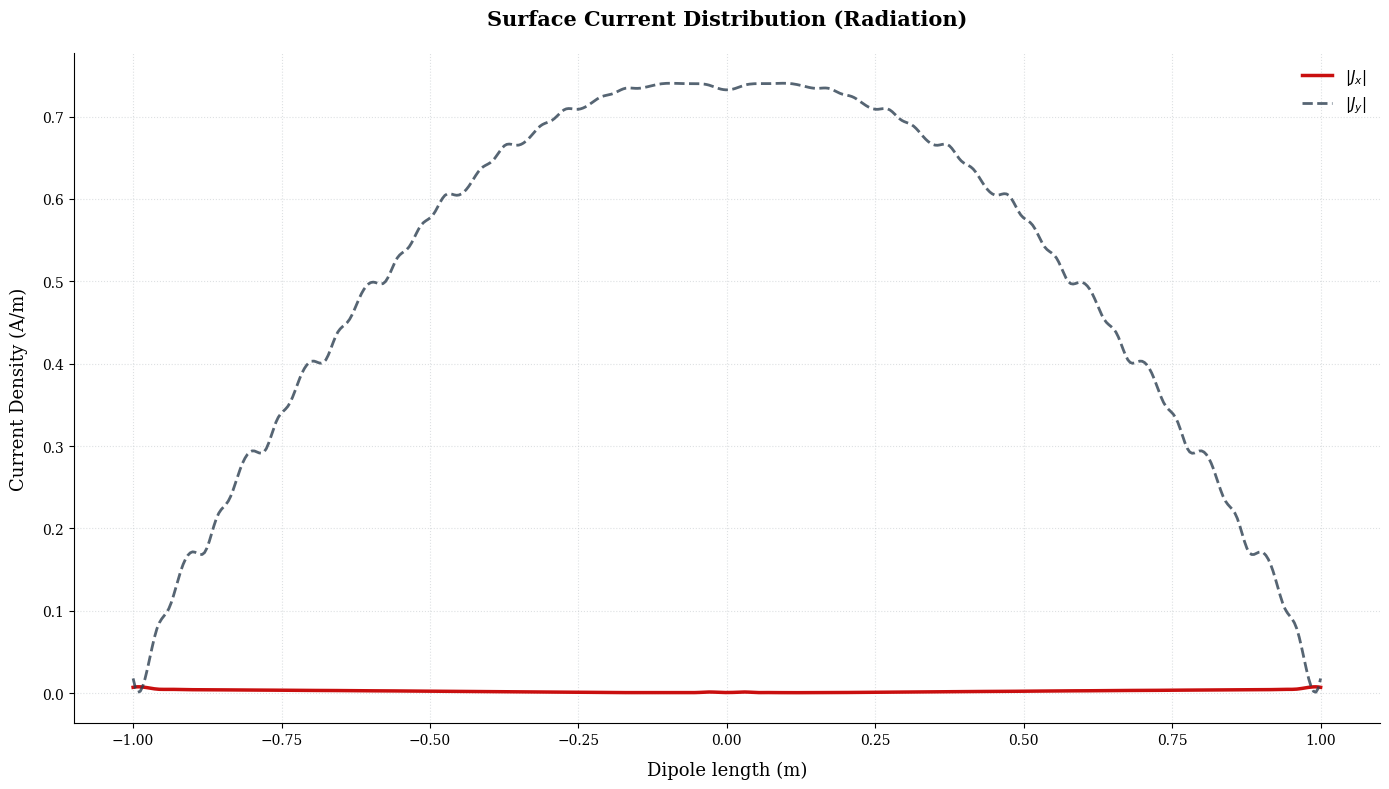

In [8]:
plot_surface_current_distribution(path, mode='radiation')